Estadísticas agregadas por cripto:

  cripto_id  retorno_promedio_diario  volatilidad  ratio_riesgo_retorno  \
3       UNI                 4.614352    47.453290              0.097240   
1      DOGE                 5.236235    60.192963              0.086991   
0       BTC                 1.509062    21.216388              0.071127   
2       NEO                14.947273   265.397254              0.056320   
4       ZEN                41.217239  1800.406553              0.022893   

   precio_minimo fecha_precio_minimo  drawdown_max  
3             36          2020-12-27        998396  
1              1          2017-05-06        992752  
0              2          2010-12-09       9100324  
2             59          2018-12-11        996136  
4             10          2025-07-21       2028337  

RECOMENDACIÓN ESTADÍSTICA
Cripto más eficiente según ratio riesgo/retorno: UNI
Ratio riesgo/retorno: 0.0972
Precio mínimo histórico: 36
Fecha óptima para comprar: 2020-12-27
Drawdown máximo hist

C:\Users\alefe\AppData\Local\Temp\ipykernel_17896\3299181019.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)
C:\Users\alefe\AppData\Local\Temp\ipykernel_17896\3299181019.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estadisticas = df.groupby("cripto_id").apply(calcular_estadisticas).reset_index()


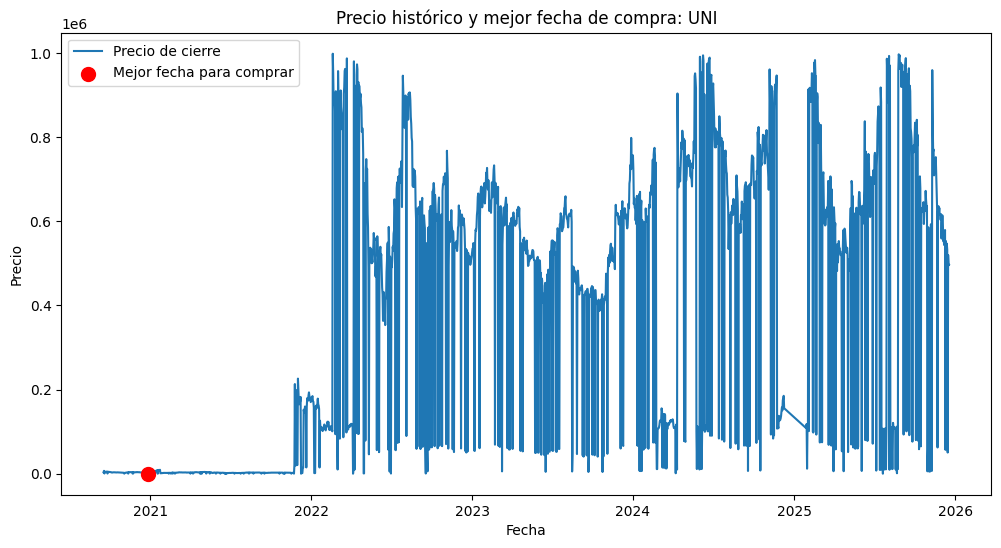

Recomendación estadística guardada en: ../datos/procesados/recomendacion_estadistica.csv


In [1]:
# 04_recomendaciones_estadisticas.ipynb
# Recomendaciones estadísticas para compra de criptomonedas
# Basado en retornos, volatilidad, drawdown y precio mínimo histórico

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1. Cargar dataset unificado
# -----------------------------
ruta_csv = "../datos/procesados/precios_diarios.csv"
df = pd.read_csv(ruta_csv, encoding="utf-8", sep=';')
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)

# Ordenar por cripto y fecha
df = df.sort_values(["cripto_id", "fecha"]).reset_index(drop=True)

# -----------------------------
# 2. Calcular retornos diarios
# -----------------------------
df["retorno_diario"] = df.groupby("cripto_id")["cierre"].pct_change()

# -----------------------------
# 3. Calcular drawdown diario
# -----------------------------
df["cierre_max"] = df.groupby("cripto_id")["cierre"].cummax()
df["drawdown"] = df["cierre_max"] - df["cierre"]

# -----------------------------
# 4. Estadísticas agregadas por cripto
# -----------------------------
def calcular_estadisticas(grupo):
    retorno = grupo["retorno_diario"].dropna()
    precio_min = grupo.loc[grupo["cierre"].idxmin()]
    drawdown_max = grupo["drawdown"].max()
    ratio_riesgo_retorno = retorno.mean() / retorno.std() if retorno.std() != 0 else np.nan
    
    return pd.Series({
        "retorno_promedio_diario": retorno.mean(),
        "volatilidad": retorno.std(),
        "ratio_riesgo_retorno": ratio_riesgo_retorno,
        "precio_minimo": precio_min["cierre"],
        "fecha_precio_minimo": precio_min["fecha"],
        "drawdown_max": drawdown_max
    })

estadisticas = df.groupby("cripto_id").apply(calcular_estadisticas).reset_index()
estadisticas = estadisticas.sort_values("ratio_riesgo_retorno", ascending=False)

print("Estadísticas agregadas por cripto:\n")
print(estadisticas)

# -----------------------------
# 5. Recomendar cripto y fecha de compra
# -----------------------------
# La cripto con mejor ratio riesgo/retorno
cripto_recomendada = estadisticas.iloc[0]

print("\nRECOMENDACIÓN ESTADÍSTICA")
print(f"Cripto más eficiente según ratio riesgo/retorno: {cripto_recomendada['cripto_id']}")
print(f"Ratio riesgo/retorno: {cripto_recomendada['ratio_riesgo_retorno']:.4f}")
print(f"Precio mínimo histórico: {cripto_recomendada['precio_minimo']}")
print(f"Fecha óptima para comprar: {cripto_recomendada['fecha_precio_minimo'].date()}")
print(f"Drawdown máximo histórico: {cripto_recomendada['drawdown_max']}")

# Explicación estadística:
print("\nEXPLICACIÓN ESTADÍSTICA:")
print("- Esta cripto tiene el mayor retorno promedio diario relativo a su volatilidad.")
print("- Comprar en la fecha del precio mínimo histórico habría reducido riesgo y maximizado potencial de ganancia.")
print("- Considerando drawdown máximo, esta fecha representa un momento seguro en términos de caída relativa.")
print("- Estos indicadores combinados sugieren que históricamente, esta cripto fue la opción más eficiente y segura para comprar.")

# -----------------------------
# 6. Visualización
# -----------------------------
plt.figure(figsize=(12,6))
subset = df[df["cripto_id"] == cripto_recomendada["cripto_id"]]
plt.plot(subset["fecha"], subset["cierre"], label="Precio de cierre")
plt.scatter(cripto_recomendada["fecha_precio_minimo"], cripto_recomendada["precio_minimo"],
            color="red", label="Mejor fecha para comprar", zorder=5, s=100)
plt.title(f"Precio histórico y mejor fecha de compra: {cripto_recomendada['cripto_id']}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

# -----------------------------
# 7. Guardar recomendaciones en CSV
# -----------------------------
ruta_recomendacion = "../datos/procesados/recomendacion_estadistica.csv"
estadisticas.to_csv(ruta_recomendacion, index=False, encoding="utf-8", sep=';')
print(f"Recomendación estadística guardada en: {ruta_recomendacion}")
